# Compare Models: Reconstruction Errors and MST Metrics
Load summary JSON outputs created by notebook 11 and compare models.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [2]:
project_root = Path.cwd().resolve().parent
results_root = project_root / "results_cholesky"

DATASET_NAME = "data_00_20_w724_s10"
DATASET = 'train'  # 'train', 'val', 'test' or 'all'
dataset_dir = results_root / DATASET_NAME
analysis_dir = dataset_dir / f"reconstruction_analysis_{DATASET}"
comparison_dir = dataset_dir / f"comparison_{DATASET}"
comparison_dir.mkdir(parents=True, exist_ok=True)

if not dataset_dir.exists():
    available = [p.name for p in results_root.iterdir() if p.is_dir()]
    raise FileNotFoundError(f"Dataset not found: {dataset_dir}. Available: {available}")

if not analysis_dir.exists():
    raise FileNotFoundError(f"Missing reconstruction_analysis folder: {analysis_dir}")

model_dirs = sorted([p for p in analysis_dir.iterdir() if p.is_dir()])
model_names = [p.name for p in model_dirs]

print(f"Models found ({len(model_names)}): {model_names}")

Models found (15): ['AE_100dim_cholesky_02_', 'AE_10dim_cholesky_01', 'AE_20dim_cholesky_03_', 'AE_3dim_cholesky_01', 'linearAE_100dim_cholesky_01', 'linearAE_10dim_cholesky_01', 'linearAE_20dim_cholesky_01', 'linearAE_3dim_cholesky_01', 'PCA_100dim', 'PCA_10dim', 'PCA_20dim', 'PCA_3dim', 'VAE_10dim_cholesky_08_loss', 'VAE_20dim_cholesky_06_loss', 'VAE_30dim_cholesky_07_loss']


In [3]:
import re


def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def flatten_metric_stats(metrics_dict, prefix=""):
    flat = {}
    for metric, stats in metrics_dict.items():
        for stat, val in stats.items():
            key = f"{prefix}{metric}_{stat}"
            flat[key] = val
    return flat


def load_model_stats(model_dir: Path):
    records = []

    errors_path = model_dir / f"reconstruction_errors_{DATASET}.json"
    if errors_path.exists():
        payload = load_json(errors_path)

        if isinstance(payload, dict):
            record = {"model": model_dir.name}
            errors_block = payload.get("reconstruction_errors")
            mst_block = payload.get("mst_metrics")

            if errors_block is None and "MSE" in payload:
                errors_block = payload

            if errors_block is not None:
                record.update(flatten_metric_stats(errors_block, prefix="err_"))
            else:
                print(f"Missing reconstruction_errors block for {model_dir.name}")

            if mst_block is not None:
                record.update(flatten_metric_stats(mst_block, prefix="mst_"))
            else:
                print(f"Missing mst_metrics block for {model_dir.name}")

            records.append(record)
        elif isinstance(payload, list):
            if payload:
                sweep_df = pd.DataFrame(payload)
                for _, row in sweep_df.iterrows():
                    k = None
                    if "n_components" in row and pd.notna(row["n_components"]):
                        k = int(row["n_components"])

                    model_name = f"{model_dir.name}_{k}" if k is not None else model_dir.name
                    record = {"model": model_name}

                    err_block = None
                    row_errs = row.get("reconstruction_errors")
                    if isinstance(row_errs, dict):
                        err_block = row_errs
                    else:
                        err_block = {}
                        if "MSE_mean" in row and pd.notna(row["MSE_mean"]):
                            err_block.setdefault("MSE", {})["mean"] = float(row["MSE_mean"])
                        if "MAE_mean" in row and pd.notna(row["MAE_mean"]):
                            err_block.setdefault("MAE", {})["mean"] = float(row["MAE_mean"])
                        if "Frobenius_mean" in row and pd.notna(row["Frobenius_mean"]):
                            err_block.setdefault("Frobenius", {})["mean"] = float(row["Frobenius_mean"])
                        if not err_block:
                            err_block = None

                    if err_block is not None:
                        record.update(flatten_metric_stats(err_block, prefix="err_"))
                    else:
                        print(f"Missing reconstruction_errors block for {model_name}")

                    if "mean_explained_variance" in row and pd.notna(row["mean_explained_variance"]):
                        record["pca_mean_explained_variance"] = float(row["mean_explained_variance"])
                    if k is not None:
                        record["pca_selected_k"] = k

                    records.append(record)
            else:
                print(f"Empty reconstruction_errors list for {model_dir.name}")
        else:
            print(f"Unexpected reconstruction_errors format for {model_dir.name}")
    else:
        print(f"Missing reconstruction_errors.json for {model_dir.name}")

    return records


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    if method == "linearAE" and "biasfalse" in model_name.lower():
        method = "linearAE_biasFalse"
    if method == "AE" and "relu" in model_name.lower():
        method = "AE_ReLU"

    k = None
    dim_match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if dim_match:
        k = int(dim_match.group(1))
    else:
        after_method = re.search(r"^[^_]+_(\d+)(?:_|$)", model_name)
        if after_method:
            k = int(after_method.group(1))
        else:
            any_num = re.search(r"(\d+)", model_name)
            if any_num:
                k = int(any_num.group(1))

    return method, k


def extract_run_id(model_name: str, k):
    nums = [int(x) for x in re.findall(r"(\d+)", model_name)]
    if not nums:
        return None
    if k is None:
        return nums[-1]
    for value in reversed(nums):
        if value != k:
            return value
    return None


method_order = ["PCA", "linearAE_biasFalse", "linearAE", "AE", "AE_ReLU"]
method_rank = {m: i for i, m in enumerate(method_order)}


def model_sort_key(model_name: str):
    method, k = parse_model_name(model_name)
    run_id = extract_run_id(model_name, k)
    method_pos = method_rank.get(method, len(method_order))
    k_pos = k if k is not None else float("inf")
    run_pos = run_id if run_id is not None else float("inf")
    return (method_pos, k_pos, run_pos, model_name.lower())


def sort_by_method_k(df: pd.DataFrame):
    ordered_index = sorted(df.index, key=model_sort_key)
    return df.loc[ordered_index]


print(model_dirs)
records_nested = [load_model_stats(p) for p in model_dirs]
records = [record for sublist in records_nested for record in sublist]
stats_df = pd.DataFrame(records).set_index("model").sort_index()
stats_df = sort_by_method_k(stats_df)
stats_df

[WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results_cholesky/data_00_20_w724_s10/reconstruction_analysis_train/AE_100dim_cholesky_02_'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results_cholesky/data_00_20_w724_s10/reconstruction_analysis_train/AE_10dim_cholesky_01'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results_cholesky/data_00_20_w724_s10/reconstruction_analysis_train/AE_20dim_cholesky_03_'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results_cholesky/data_00_20_w724_s10/reconstruction_analysis_train/AE_3dim_cholesky_01'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results_cholesky/data_00_20_w724_s10/reconstruction_analysis_train/linearAE_100dim_cholesky_01'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results_cholesky/data_00_

,err_MSE_mean,err_MSE_std,err_MSE_min,err_MSE_median,err_MSE_max,err_MAE_mean,err_MAE_std,err_MAE_min,err_MAE_median,err_MAE_max,err_Frobenius_mean,err_Frobenius_std,err_Frobenius_min,err_Frobenius_median,err_Frobenius_max,mst_edge_overlap_pct_count,mst_edge_overlap_pct_mean,mst_edge_overlap_pct_std,mst_edge_overlap_pct_min,mst_edge_overlap_pct_25%,mst_edge_overlap_pct_50%,mst_edge_overlap_pct_75%,mst_edge_overlap_pct_max,mst_edge_jaccard_pct_count,mst_edge_jaccard_pct_mean,...,mst_avg_path_len_unweighted_max,mst_avg_path_len_unweighted_recon_count,mst_avg_path_len_unweighted_recon_mean,mst_avg_path_len_unweighted_recon_std,mst_avg_path_len_unweighted_recon_min,mst_avg_path_len_unweighted_recon_25%,mst_avg_path_len_unweighted_recon_50%,mst_avg_path_len_unweighted_recon_75%,mst_avg_path_len_unweighted_recon_max,mst_avg_path_len_unweighted_diff_count,mst_avg_path_len_unweighted_diff_mean,mst_avg_path_len_unweighted_diff_std,mst_avg_path_len_unweighted_diff_min,mst_avg_path_len_unweighted_diff_25%,mst_avg_path_len_unweighted_diff_50%,mst_avg_path_len_unweighted_diff_75%,mst_avg_path_len_unweighted_diff_max,mst_betweenness_topk_overlap_pct_count,mst_betweenness_topk_overlap_pct_mean,mst_betweenness_topk_overlap_pct_std,mst_betweenness_topk_overlap_pct_min,mst_betweenness_topk_overlap_pct_25%,mst_betweenness_topk_overlap_pct_50%,mst_betweenness_topk_overlap_pct_75%,mst_betweenness_topk_overlap_pct_max
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PCA_3dim,3.379320e-03,0.002143,5.981681e-04,2.783794e-03,0.009170,0.045245,0.014914,0.019016,0.042744,0.081697,20.073055,6.328591,8.853606,19.099724,34.664970,288.0,57.278201,10.320190,35.180055,50.069252,58.587258,65.650970,76.454294,288.0,40.853463,...,14.683491,288.0,10.224141,1.416775,8.124853,8.962914,9.847469,11.221006,12.912322,288.0,1.091923,0.846896,0.000888,0.455342,0.894974,1.439135,4.029996,288.0,44.131944,18.115290,0.0,30.0,50.0,60.0,80.0
PCA_10dim,4.864585e-04,0.000309,9.176862e-05,4.104940e-04,0.002642,0.016236,0.005088,0.007183,0.015528,0.038817,7.689344,2.153500,3.467813,7.334349,18.608400,288.0,78.217336,5.570264,59.833795,74.445983,78.947368,81.994460,89.750693,288.0,64.564681,...,14.683491,288.0,10.320501,1.554888,6.995623,9.066585,10.065602,11.266494,14.724293,288.0,0.934418,0.765063,0.006321,0.319554,0.791433,1.335486,4.525076,288.0,63.368056,16.383150,20.0,50.0,60.0,80.0,100.0
PCA_20dim,2.136334e-04,0.000200,7.154148e-05,1.644789e-04,0.002742,0.010404,0.003733,0.005064,0.009631,0.039374,5.026091,1.656296,3.061876,4.642623,18.955851,288.0,84.902085,4.248314,67.313019,82.479224,85.595568,88.088643,93.074792,288.0,73.995348,...,14.683491,288.0,10.455761,1.452927,7.611760,9.388615,10.128564,11.495099,13.686124,288.0,0.644649,0.603779,0.000077,0.207056,0.459994,0.913997,3.820909,288.0,74.618056,16.898754,20.0,70.0,80.0,90.0,100.0
PCA_100dim,1.972191e-05,0.000011,7.653960e-07,1.751747e-05,0.000104,0.003005,0.000691,0.000688,0.002980,0.004669,1.555969,0.404929,0.316703,1.515109,3.700112,288.0,94.415589,1.783314,89.750693,93.282548,94.459834,95.637119,99.168975,288.0,89.475565,...,14.683491,288.0,10.419362,1.545658,6.989134,9.397660,10.074739,11.640058,14.857609,288.0,0.386222,0.440089,0.003122,0.082307,0.225525,0.542653,2.718477,288.0,86.180556,14.264623,30.0,80.0,90.0,100.0,100.0
linearAE_3dim_cholesky_01,4.112135e-03,0.003535,7.189442e-04,2.637851e-03,0.015552,0.049095,0.021512,0.020847,0.040400,0.103458,21.475609,8.828332,9.706354,18.592316,45.143864,288.0,58.223684,11.485608,33.518006,49.861496,59.279778,67.313019,77.839335,288.0,41.984758,...,14.683491,288.0,10.067391,1.374899,7.270871,9.151964,9.747525,11.324425,12.542033,288.0,1.075675,0.884444,0.002525,0.341168,0.893834,1.560433,4.153212,288.0,46.388889,18.911535,0.0,30.0,50.0,60.0,80.0
linearAE_10dim_cholesky_01,6.006319e-04,0.000489,1.133656e-04,4.647544e-04,0.004554,0.018083,0.007222,0.008087,0.016536,0.053662,8.386178,2.900074,3.854333,7.804044,24.430054,288.0,78.364497,5.504117,60.110803,75.069252,79

In [4]:
err_metrics = ["MSE", "MAE", "Frobenius"]

available_err_metrics = [
    m for m in err_metrics if f"err_{m}_mean" in stats_df.columns
]
if not available_err_metrics:
    raise KeyError("No reconstruction error metrics found. Check JSON files.")

err_means = pd.DataFrame(
    {m: stats_df[f"err_{m}_mean"] for m in available_err_metrics},
    index=stats_df.index,
)
err_stds = pd.DataFrame(
    {m: stats_df[f"err_{m}_std"] for m in available_err_metrics},
    index=stats_df.index,
)

def reshape_to_matrix(series_or_df, metric_name):
    if isinstance(series_or_df, pd.DataFrame):
        df_temp = series_or_df[[metric_name]].copy()
    else:
        df_temp = series_or_df.to_frame(name=metric_name)

    df_flat = df_temp.reset_index()
    model_col = "model" if "model" in df_flat.columns else df_flat.columns[0]
    df_flat[["method", "K"]] = df_flat[model_col].apply(
        lambda x: pd.Series(parse_model_name(x))
    )
    df_flat["K"] = pd.to_numeric(df_flat["K"], errors="coerce")
    df_flat = df_flat.dropna(subset=["method", "K"]).copy()

    # If multiple runs exist for the same method/K, average them.
    grouped = (
        df_flat.groupby(["method", "K"], as_index=False)[metric_name]
        .mean()
    )
    matrix_df = grouped.pivot(index="method", columns="K", values=metric_name)

    ordered_methods = [m for m in method_order if m in matrix_df.index]
    ordered_methods += [m for m in matrix_df.index if m not in ordered_methods]
    matrix_df = matrix_df.reindex(ordered_methods)
    matrix_df = matrix_df.reindex(sorted(matrix_df.columns), axis=1)
    return matrix_df

def combine_mean_std(means_df, stds_df, metric_name, precision=2):
    mean_mat = reshape_to_matrix(means_df, metric_name)
    std_mat = reshape_to_matrix(stds_df, metric_name)
    mean_mat, std_mat = mean_mat.align(std_mat)

    def fmt(m, s):
        if pd.isna(m):
            return np.nan
        mean_str = f"{m:.{precision}e}"
        if pd.isna(s):
            return mean_str
        std_str = f"{s:.{precision}e}"
        return f"{mean_str} +/- {std_str}"

    combined = mean_mat.astype(object)
    for row in mean_mat.index:
        for col in mean_mat.columns:
            combined.loc[row, col] = fmt(mean_mat.loc[row, col], std_mat.loc[row, col])
    return combined

for metric in available_err_metrics:
    print(f"\n" + "="*40)
    print(f" METRICA: {metric}")
    print("="*40)

    combined = combine_mean_std(err_means, err_stds, metric)
    display(combined)
    out_path = comparison_dir / f"err_{metric}_mean_std.csv"
    combined.to_csv(out_path)

err_ranks = err_means.rank(axis=0, ascending=True)
err_ranks["avg_rank"] = err_ranks.mean(axis=1)


 METRICA: MSE


K,3,10,20,30,100
method,,,,,
PCA,3.38e-03 +/- 2.14e-03,4.86e-04 +/- 3.09e-04,2.14e-04 +/- 2.00e-04,NaN,1.97e-05 +/- 1.11e-05
linearAE,4.11e-03 +/- 3.53e-03,6.01e-04 +/- 4.89e-04,2.78e-04 +/- 3.81e-04,NaN,2.33e-05 +/- 1.60e-05
AE,6.89e-05 +/- 6.84e-05,2.11e-06 +/- 3.93e-06,7.23e-07 +/- 3.18e-06,NaN,8.83e-07 +/- 2.17e-06
VAE,NaN,6.33e-05 +/- 5.30e-05,8.69e-05 +/- 7.69e-05,1.16e-04 +/- 1.28e-04,NaN



 METRICA: MAE


K,3,10,20,30,100
method,,,,,
PCA,4.52e-02 +/- 1.49e-02,1.62e-02 +/- 5.09e-03,1.04e-02 +/- 3.73e-03,NaN,3.00e-03 +/- 6.91e-04
linearAE,4.91e-02 +/- 2.15e-02,1.81e-02 +/- 7.22e-03,1.18e-02 +/- 5.64e-03,NaN,3.22e-03 +/- 9.10e-04
AE,6.00e-03 +/- 2.99e-03,9.54e-04 +/- 7.60e-04,3.88e-04 +/- 2.51e-04,NaN,5.02e-04 +/- 3.04e-04
VAE,NaN,5.39e-03 +/- 2.17e-03,6.44e-03 +/- 2.66e-03,7.42e-03 +/- 3.96e-03,NaN



 METRICA: Frobenius


K,3,10,20,30,100
method,,,,,
PCA,2.01e+01 +/- 6.33e+00,7.69e+00 +/- 2.15e+00,5.03e+00 +/- 1.66e+00,NaN,1.56e+00 +/- 4.05e-01
linearAE,2.15e+01 +/- 8.83e+00,8.39e+00 +/- 2.90e+00,5.56e+00 +/- 2.36e+00,NaN,1.67e+00 +/- 5.16e-01
AE,2.74e+00 +/- 1.23e+00,4.24e-01 +/- 3.11e-01,2.15e-01 +/- 2.21e-01,NaN,2.61e-01 +/- 2.18e-01
VAE,NaN,2.70e+00 +/- 9.92e-01,3.16e+00 +/- 1.18e+00,3.54e+00 +/- 1.62e+00,NaN


In [5]:
mst_metrics = [
    "edge_overlap_pct",
    "edge_jaccard_pct",
    "degree_l1",
    "avg_path_len_diff",
    "avg_path_len_unweighted_diff",
    "betweenness_topk_overlap_pct",
]

available_mst_metrics = [
    m for m in mst_metrics if f"mst_{m}_mean" in stats_df.columns
]
if not available_mst_metrics:
    raise KeyError("No MST metrics found. Check JSON files.")

mst_means = pd.DataFrame(
    {m: stats_df[f"mst_{m}_mean"] for m in available_mst_metrics},
    index=stats_df.index,
)
mst_stds = pd.DataFrame(index=stats_df.index)
for m in available_mst_metrics:
    std_col = f"mst_{m}_std"
    if std_col in stats_df.columns:
        mst_stds[m] = stats_df[std_col]
    else:
        mst_stds[m] = np.nan

for metric in available_mst_metrics:
    print(f"\n" + "="*40)
    print(f" METRICA: {metric}")
    print("="*40)

    combined = combine_mean_std(mst_means, mst_stds, metric)
    display(combined)
    out_path = comparison_dir / f"mst_{metric}_mean_std.csv"
    combined.to_csv(out_path)


 METRICA: edge_overlap_pct


K,3,10,20,30,100
method,,,,,
PCA,5.73e+01 +/- 1.03e+01,7.82e+01 +/- 5.57e+00,8.49e+01 +/- 4.25e+00,NaN,9.44e+01 +/- 1.78e+00
linearAE,5.82e+01 +/- 1.15e+01,7.84e+01 +/- 5.50e+00,8.51e+01 +/- 4.30e+00,NaN,9.44e+01 +/- 1.83e+00
AE,9.26e+01 +/- 2.92e+00,9.89e+01 +/- 7.81e-01,9.93e+01 +/- 6.66e-01,NaN,9.92e+01 +/- 6.89e-01
VAE,NaN,9.26e+01 +/- 2.50e+00,9.20e+01 +/- 2.62e+00,9.14e+01 +/- 2.99e+00,NaN



 METRICA: edge_jaccard_pct


K,3,10,20,30,100
method,,,,,
PCA,4.09e+01 +/- 1.00e+01,6.46e+01 +/- 7.42e+00,7.40e+01 +/- 6.27e+00,NaN,8.95e+01 +/- 3.19e+00
linearAE,4.20e+01 +/- 1.14e+01,6.48e+01 +/- 7.26e+00,7.42e+01 +/- 6.34e+00,NaN,8.94e+01 +/- 3.27e+00
AE,8.64e+01 +/- 4.92e+00,9.78e+01 +/- 1.52e+00,9.87e+01 +/- 1.30e+00,NaN,9.85e+01 +/- 1.34e+00
VAE,NaN,8.62e+01 +/- 4.27e+00,8.52e+01 +/- 4.42e+00,8.43e+01 +/- 4.99e+00,NaN



 METRICA: degree_l1


...

K,3,10,20,30,100
method,,,,,
PCA,8.70e-01 +/- 6.32e-01,6.36e-01 +/- 5.36e-01,4.47e-01 +/- 4.10e-01,NaN,2.60e-01 +/- 2.94e-01
linearAE,8.98e-01 +/- 7.02e-01,6.47e-01 +/- 5.61e-01,4.42e-01 +/- 4.19e-01,NaN,2.51e-01 +/- 2.83e-01
AE,3.20e-01 +/- 3.58e-01,1.11e-01 +/- 2.32e-01,5.34e-02 +/- 1.44e-01,NaN,6.57e-02 +/- 1.67e-01
VAE,NaN,3.14e-01 +/- 3.29e-01,3.06e-01 +/- 3.07e-01,2.93e-01 +/- 3.10e-01,NaN



 METRICA: avg_path_len_unweighted_diff


K,3,10,20,30,100
method,,,,,
PCA,1.09e+00 +/- 8.47e-01,9.34e-01 +/- 7.65e-01,6.45e-01 +/- 6.04e-01,NaN,3.86e-01 +/- 4.40e-01
linearAE,1.08e+00 +/- 8.84e-01,9.24e-01 +/- 7.86e-01,6.19e-01 +/- 5.87e-01,NaN,3.72e-01 +/- 4.21e-01
AE,4.60e-01 +/- 5.15e-01,1.68e-01 +/- 3.54e-01,8.01e-02 +/- 2.21e-01,NaN,1.03e-01 +/- 2.66e-01
VAE,NaN,4.54e-01 +/- 4.78e-01,4.43e-01 +/- 4.42e-01,4.20e-01 +/- 4.50e-01,NaN



 METRICA: betweenness_topk_overlap_pct


K,3,10,20,30,100
method,,,,,
PCA,4.41e+01 +/- 1.81e+01,6.34e+01 +/- 1.64e+01,7.46e+01 +/- 1.69e+01,NaN,8.62e+01 +/- 1.43e+01
linearAE,4.64e+01 +/- 1.89e+01,6.41e+01 +/- 1.79e+01,7.35e+01 +/- 1.77e+01,NaN,8.66e+01 +/- 1.43e+01
AE,8.21e+01 +/- 1.64e+01,9.51e+01 +/- 1.10e+01,9.76e+01 +/- 7.06e+00,NaN,9.70e+01 +/- 8.27e+00
VAE,NaN,8.30e+01 +/- 1.49e+01,8.33e+01 +/- 1.48e+01,8.24e+01 +/- 1.54e+01,NaN


# K-based comparison plots
Build plots for error metrics across K and methods.

In [6]:
import re


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    

    match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if not match:
        match = re.search(r"_(\d+)(?:_|$)", model_name)
    k = int(match.group(1)) if match else None

    return method, k


model_meta = []
for model in stats_df.index:
    method, k = parse_model_name(model)
    model_meta.append({"model": model, "method": method, "K": k})

meta_df = pd.DataFrame(model_meta).set_index("model")

err_by_model = err_means.join(meta_df)
err_by_model = err_by_model.dropna(subset=["K", "method"]).copy()
err_by_model["K"] = err_by_model["K"].astype(int)

if err_by_model.empty:
    raise ValueError("No valid models with parsed K were found.")

err_long = err_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_err_metrics,
    var_name="metric",
    value_name="error",
)

method_order = ["PCA", "linearAE", "AE", "VAE"]
methods = [m for m in method_order if m in err_long["method"].unique()]
if not methods:
    methods = sorted(err_long["method"].unique())

ks_sorted = sorted(err_long["K"].unique())

method_labels = {
    "PCA": "PCA",
    "linearAE": "LinearAE",
    "AE": "AE",
    "VAE": "VAE",
}
method_colors = {
    "PCA": "tab:blue",
    "linearAE": "tab:green",
    "AE": "tab:red",
    "VAE": "tab:orange",
}

print(f"Methods: {methods}")
print(f"K values: {ks_sorted}")

Methods: ['PCA', 'linearAE', 'AE', 'VAE']
K values: [np.int64(3), np.int64(10), np.int64(20), np.int64(30), np.int64(100)]


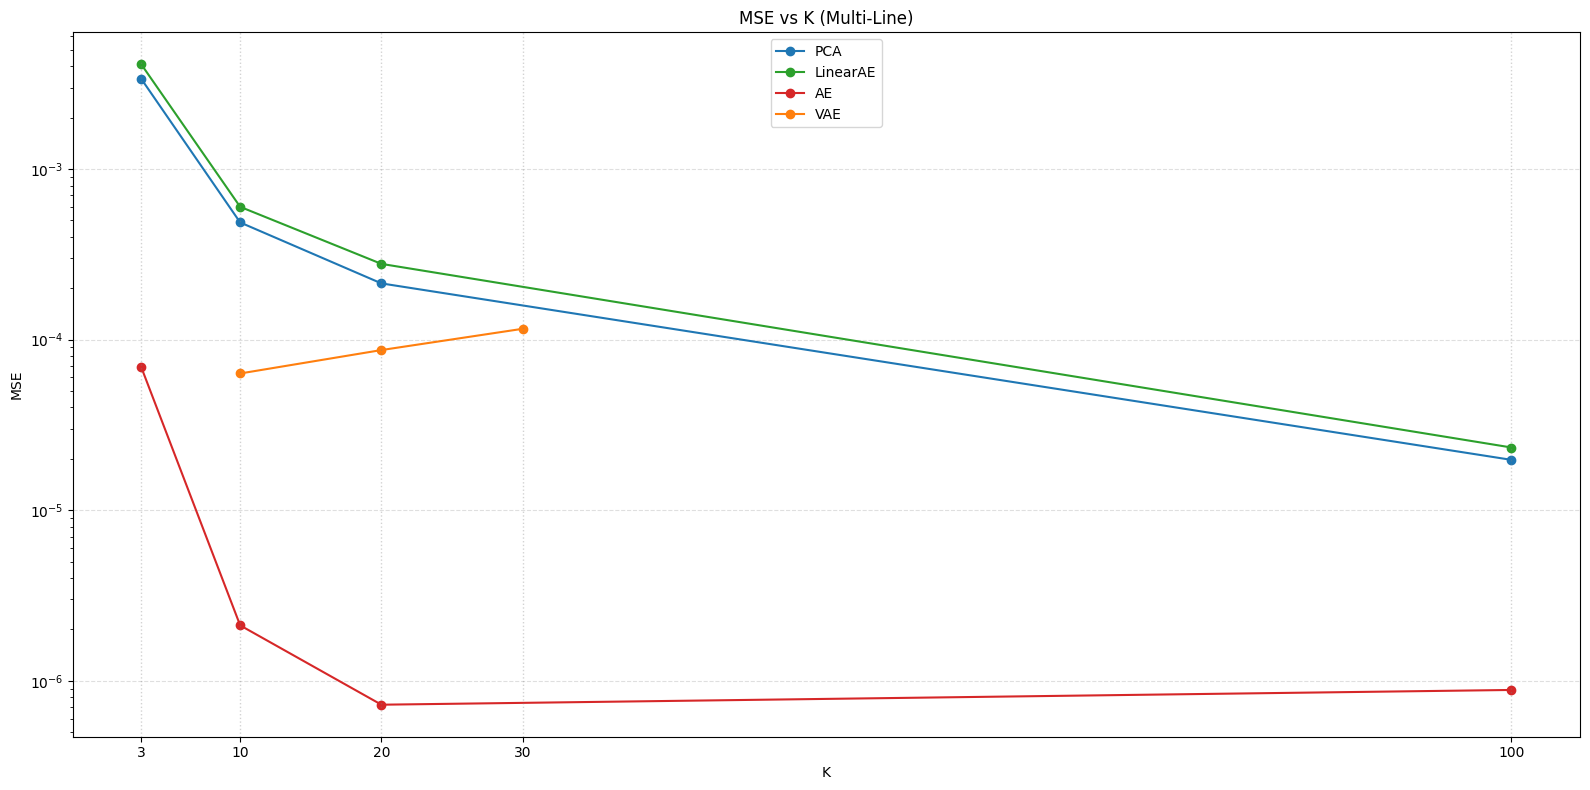

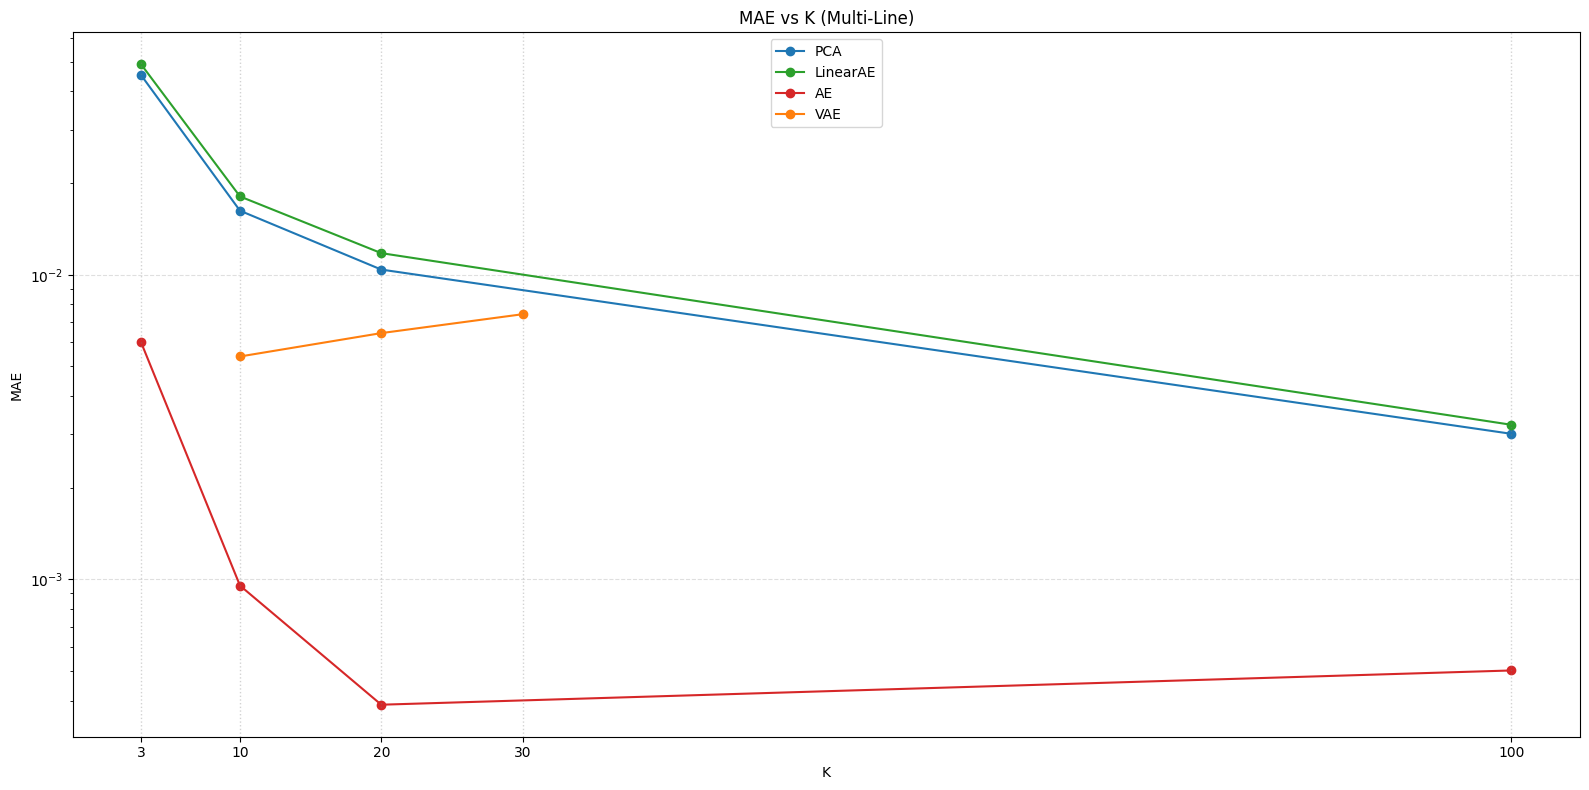

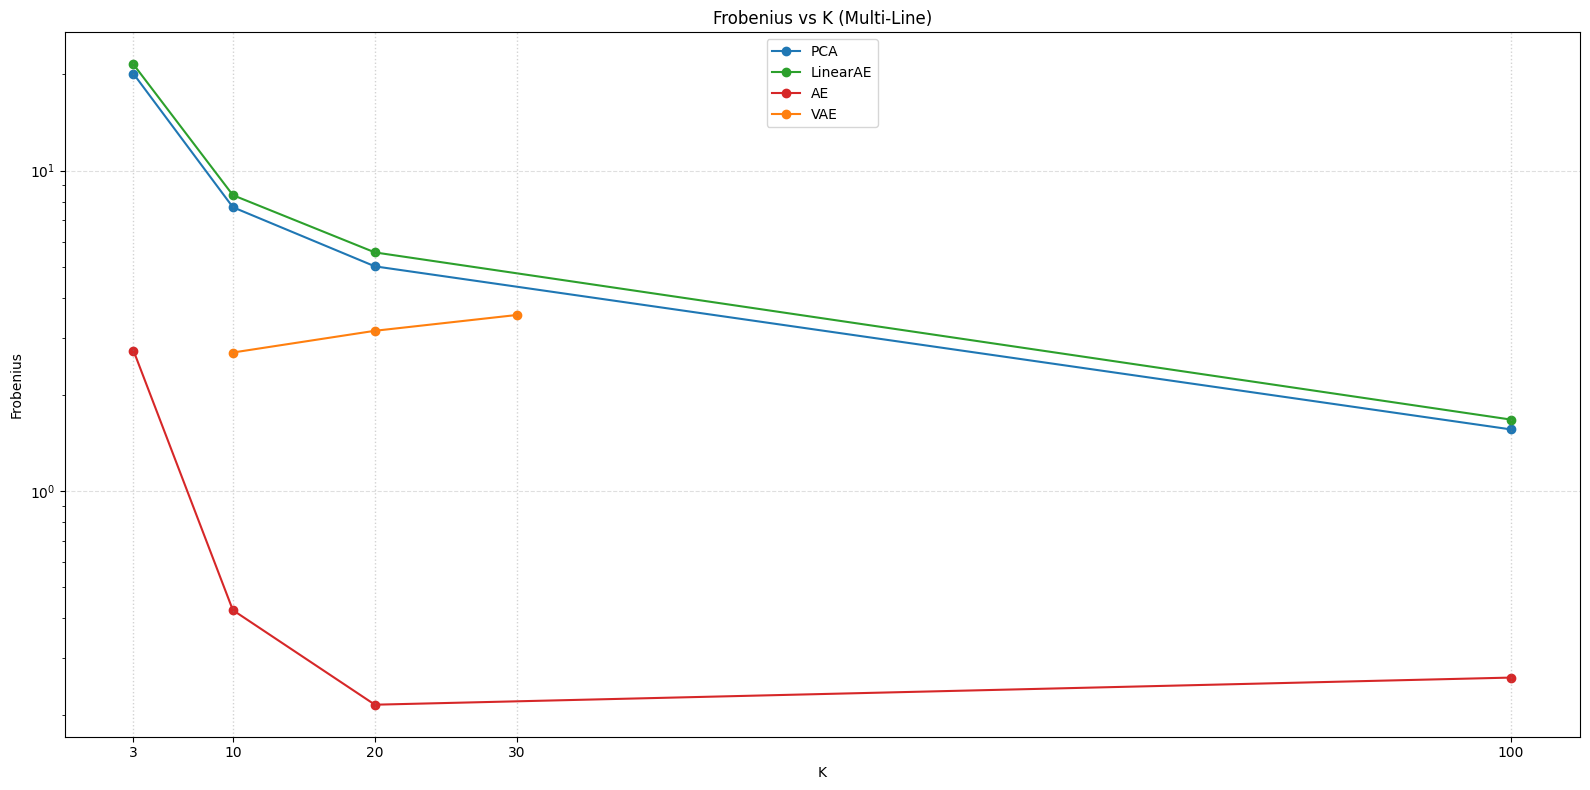

In [7]:
for metric in available_err_metrics:
    fig, ax = plt.subplots(figsize=(16, 8))
    all_x = []
    all_y = []
    for method in methods:
        subset = err_long[
            (err_long["metric"] == metric) & (err_long["method"] == method)
        ].sort_values("K")
        x_vals = subset["K"].to_numpy()
        y_vals = subset["error"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    if all_x:
        k_ticks = sorted(set(all_x))
        ax.set_xticks(k_ticks)
        for k_tick in k_ticks:
            ax.axvline(
                k_tick,
                linestyle=":",
                color="gray",
                alpha=0.35,
                linewidth=1,
            )
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plot_path = comparison_dir / f"err_{metric}_vs_k.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

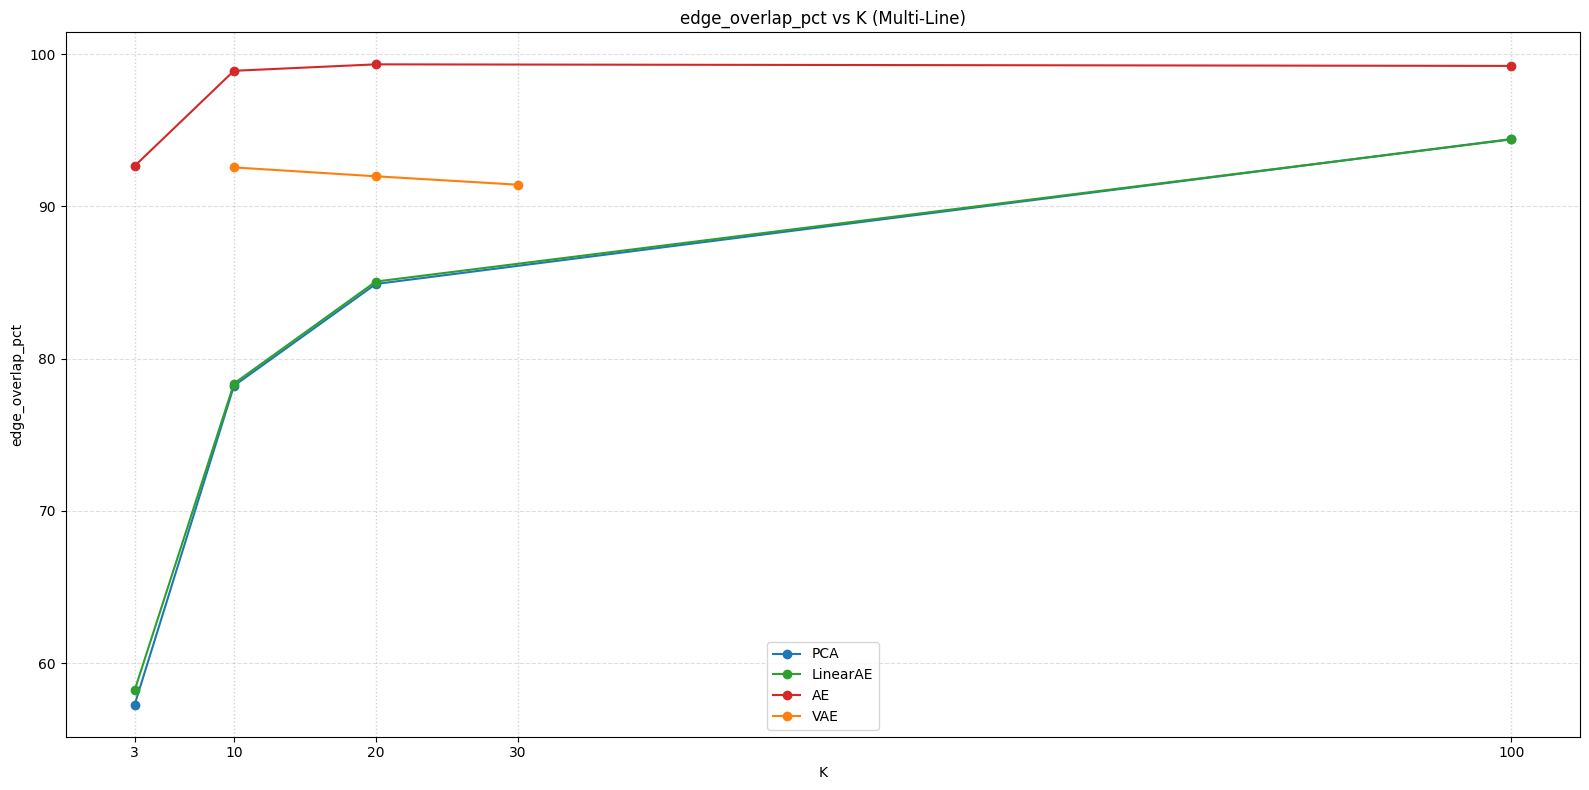

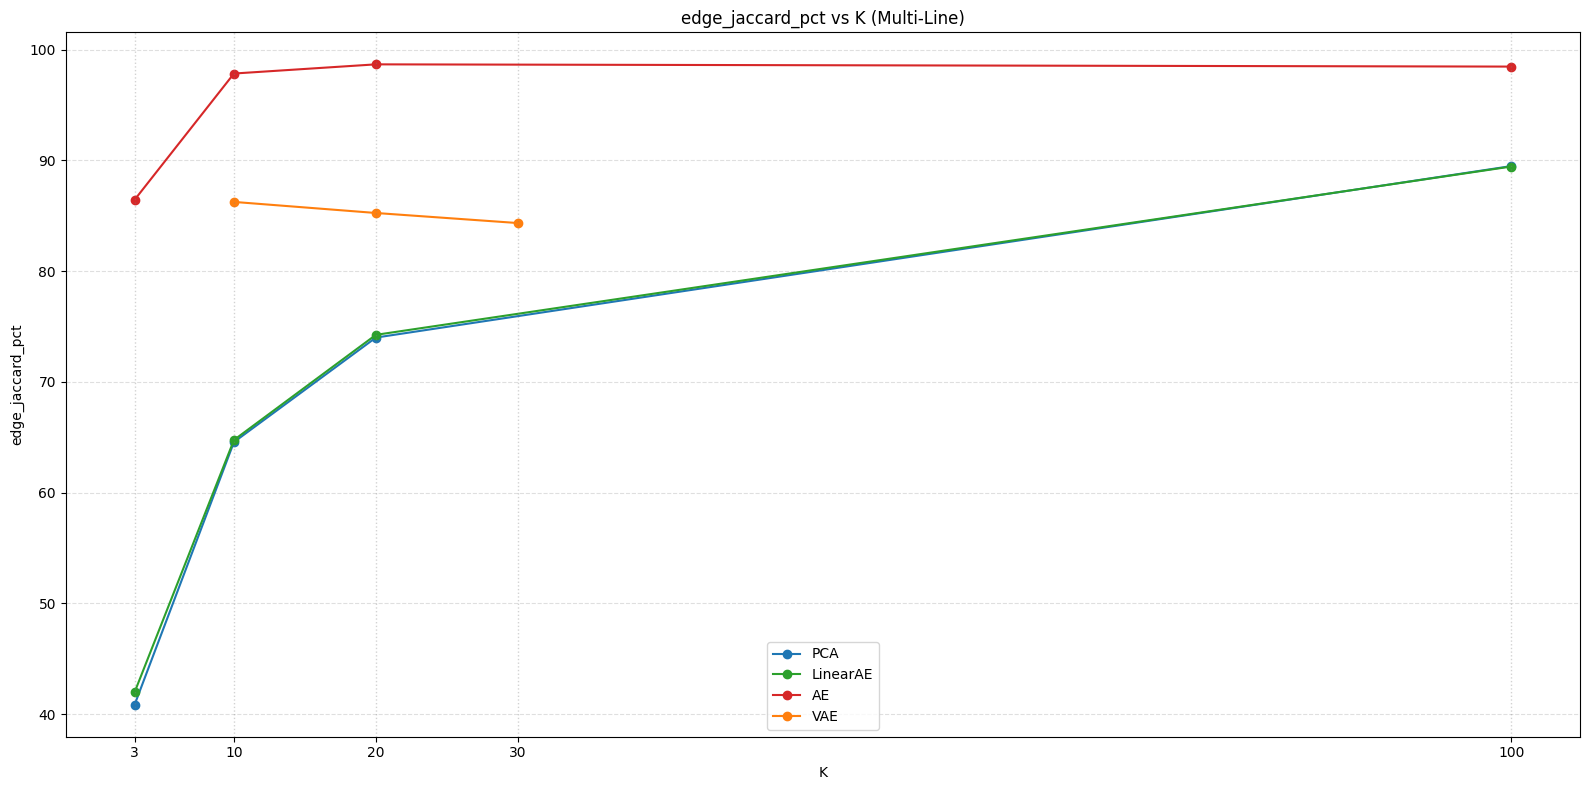

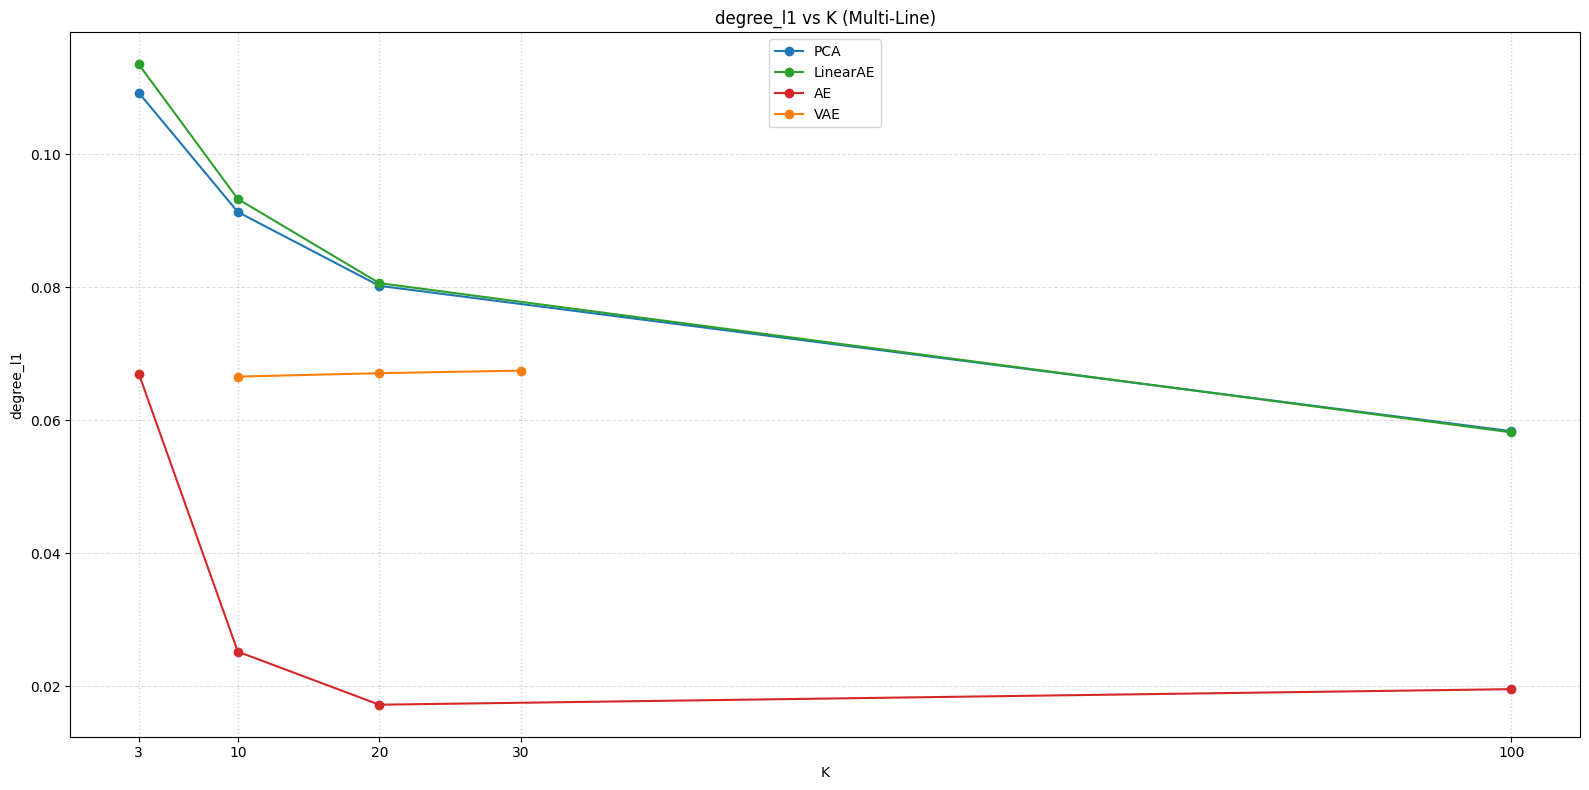

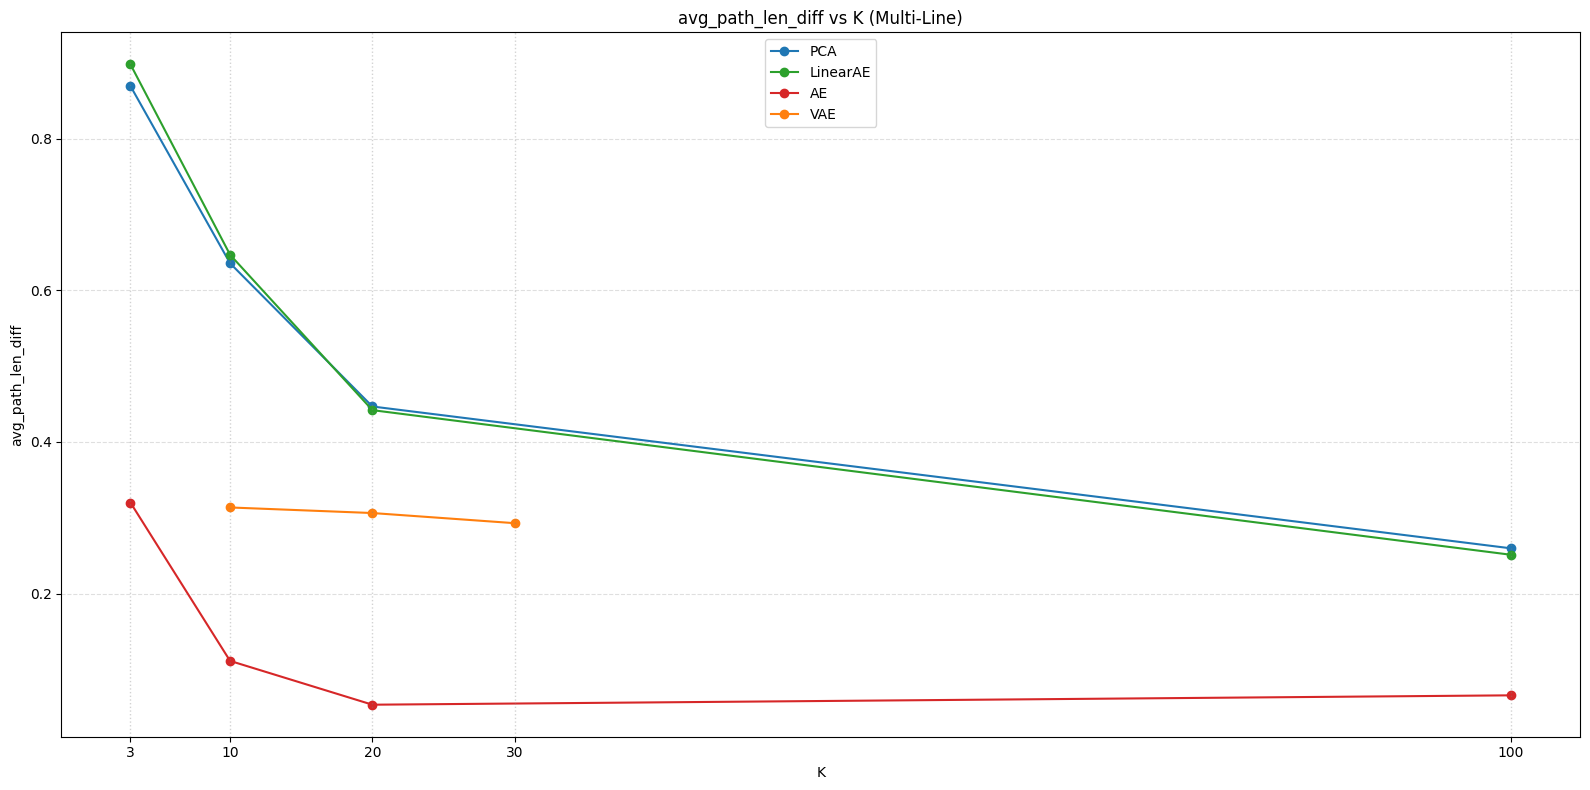

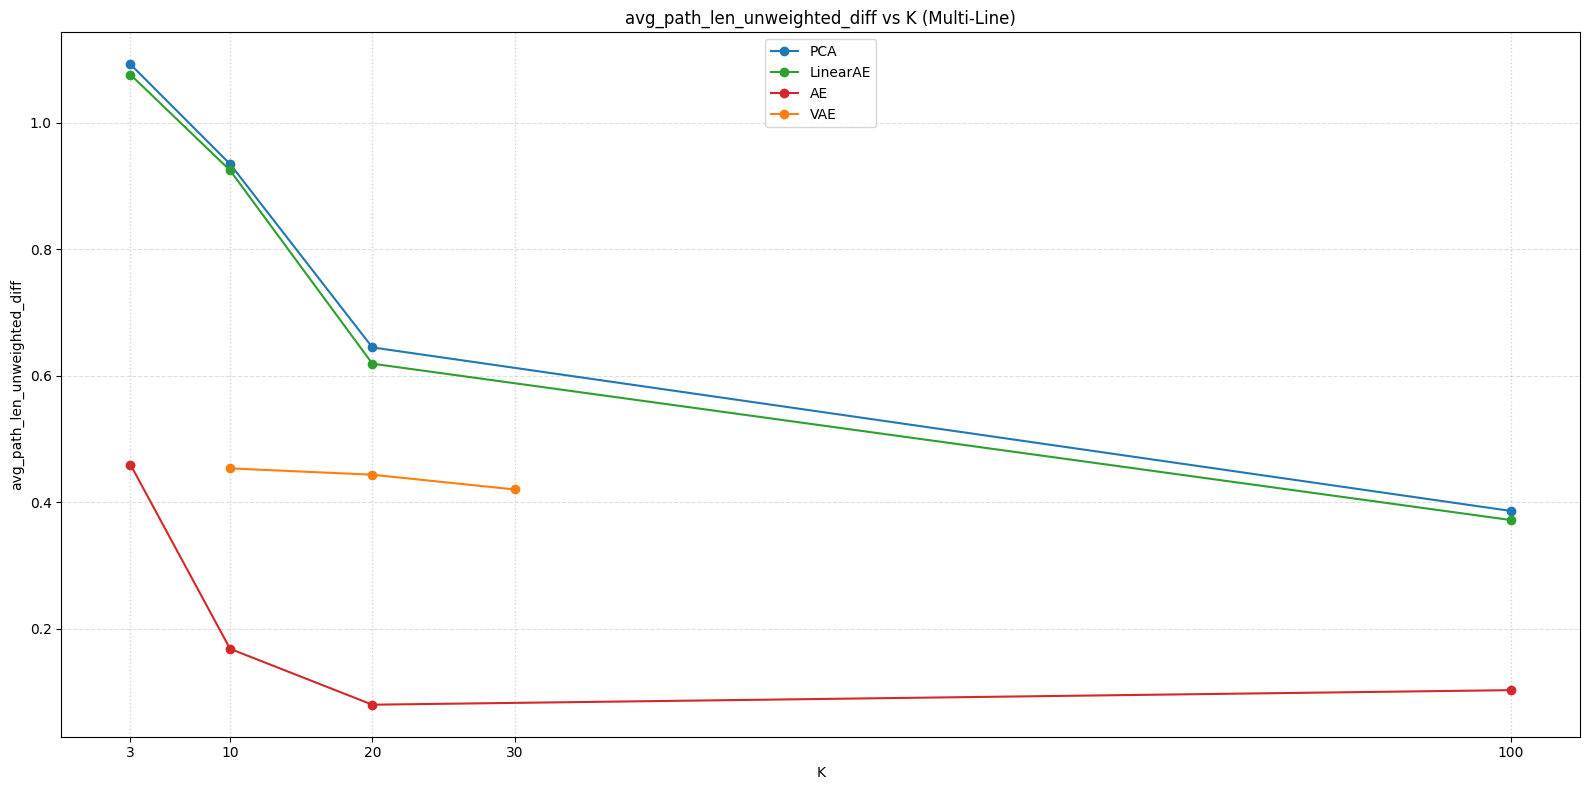

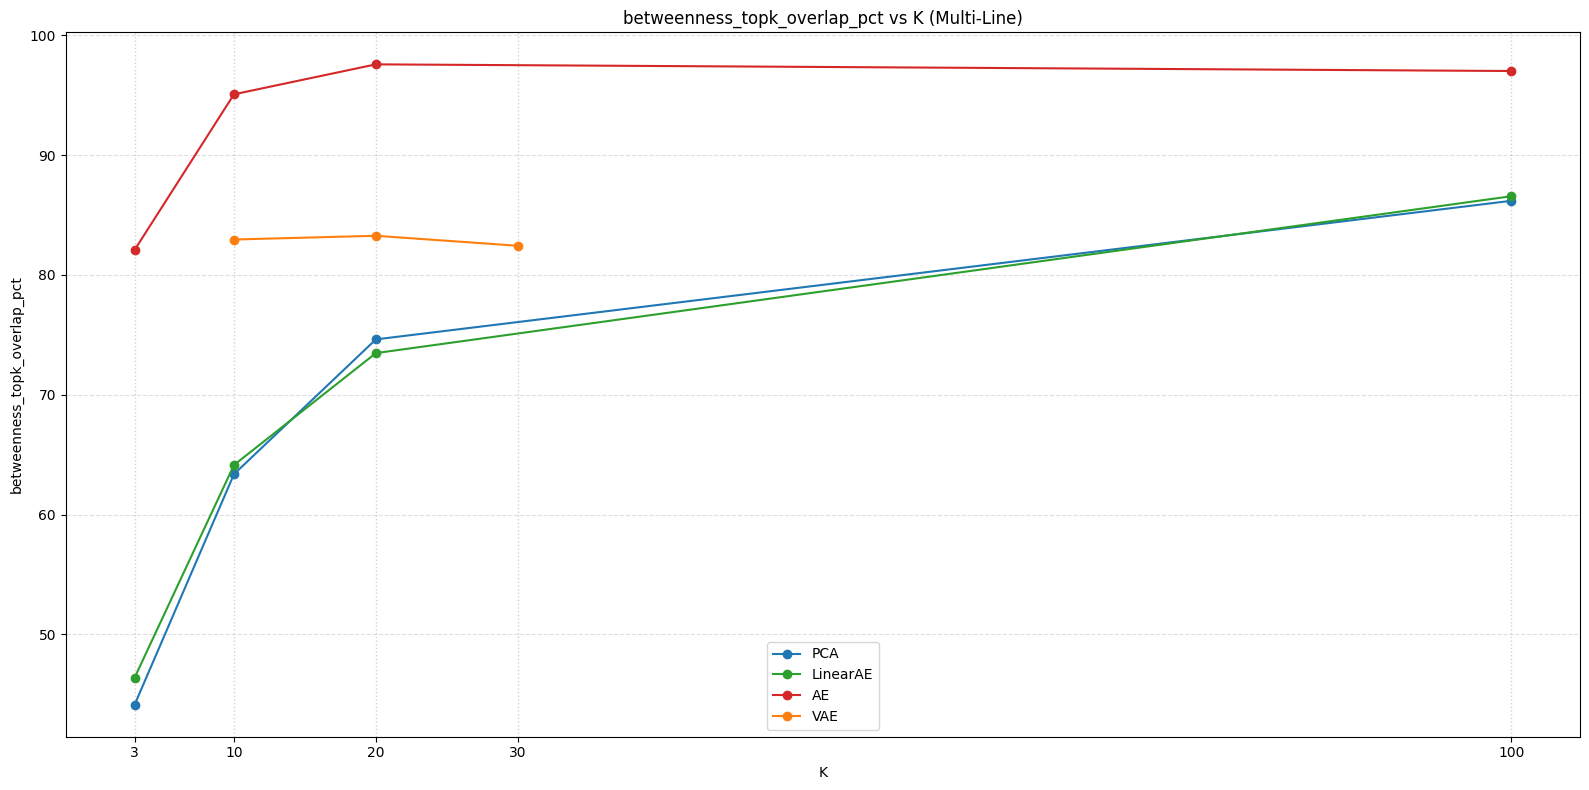

In [8]:
# MST K-based comparison plots
mst_by_model = mst_means.join(meta_df)
mst_by_model = mst_by_model.dropna(subset=["K", "method"]).copy()
mst_by_model["K"] = mst_by_model["K"].astype(int)

if mst_by_model.empty:
    raise ValueError("No valid MST models with parsed K were found.")

mst_long = mst_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_mst_metrics,
    var_name="metric",
    value_name="value",
)

mst_methods = [m for m in method_order if m in mst_long["method"].unique()]
if not mst_methods:
    mst_methods = sorted(mst_long["method"].unique())

mst_ks_sorted = sorted(mst_long["K"].unique())

for metric in available_mst_metrics:
    fig, ax = plt.subplots(figsize=(16, 8))
    all_x = []
    all_y = []
    for method in mst_methods:
        subset = mst_long[
            (mst_long["metric"] == metric) & (mst_long["method"] == method)
        ].sort_values("K")
        if subset.empty:
            continue
        x_vals = subset["K"].to_numpy()
        y_vals = subset["value"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    if all_x:
        k_ticks = sorted(set(all_x))
        ax.set_xticks(k_ticks)
        for k_tick in k_ticks:
            ax.axvline(
                k_tick,
                linestyle=":",
                color="gray",
                alpha=0.35,
                linewidth=1,
            )
    if all_y:
        y_min = min(all_y)
        y_max = max(all_y)
        if y_min > 0 and (y_max / y_min) >= 1000:
            ax.set_yscale("log")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plot_path = comparison_dir / f"mst_{metric}_vs_k.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()